# 02 — Income Classification

Build a probability-scoring model for the >$50K target. The goal is ranked marketing targeting: compare common classifier families on validation, select one final model, evaluate test once, and save a reusable prediction bundle.

| Section | What to read for |
|---|---|
| [Initial plan](#initial-plan) | How EDA findings map to modeling work. |
| [Load + preprocessing functions](#load-preprocess) | Self-contained data load, feature lists, deterministic cleaning. |
| [Train / validation / test split](#split) | Stratified split and train-only categorical maps. |
| [Logistic regression baseline](#logreg) | Interpretable baseline and education representation check. |
| [Common-model benchmark](#benchmark) | Logistic Regression, Random Forest, HistGradientBoosting, XGBoost, LightGBM. |
| [Validation comparison](#val-comparison) | Metrics, calibration check, and lift/gains on validation. |
| [Threshold + bands](#thresholds) | Business threshold framework and capacity bands. |
| [Feature importance + ablation](#ablation) | Feature importance, drop-candidate checks, sensitive-attribute sensitivity. |
| [Final test evaluation + artifact](#final-test) | One-time test evaluation and saved prediction bundle. |

<a id="initial-plan"></a>

## Initial plan

| # | EDA finding / implication | Where it is handled here |
|---|---|---|
| 1 | Dataset shape: 199,523 records, 40 features + `weight` + `label`. | Raw-load assertions in [Load + preprocessing](#load-preprocess). |
| 2 | 33 categorical and 7 numeric modeling features after integer-recode overrides. | Hardcoded feature lists and separate model representations. |
| 3 | Target imbalance: 6.21% high-income, ~15:1. | Stratified split, PR-AUC/lift metrics, validation-only model selection. |
| 4 | Sample and weighted target rates are close. | Train unweighted; report both sample and weighted metrics. |
| 5 | `Not in universe*` is information-bearing. | Preserved as its own categorical value. |
| 6 | `?`, `NaN`, and `Do not know` need explicit unknown treatment. | Deterministic cleaning + train-only category maps. |
| 7 | Numeric zero-spikes, heavy tails, and top-coding matter. | Logreg flags/log transforms; tree/boosting models use raw numerics plus top-code flag. |
| 8 | Education has the strongest categorical target relationship. | Logreg compares raw education one-hot vs. education-tier replacement. |
| 9 | Occupation, industry, and worker class carry strong signal. | Included in model benchmark; detailed/coarse redundancy tested in ablation. |
| 10 | Financial tails and full-year work are strong binary signals. | `has_X`, `log1p`, `capital_gains_at_cap`, `worked_full_year_52_weeks` for logreg. |
| 11 | Household and demographics add moderate complementary signal. | Kept as auxiliary features. |
| 12 | Migration-code fields are year artifacts; other low-signal fields need ablation. | Drop four migration artifact columns upfront; test remaining candidates. |
| 13 | Sensitive attributes need explicit limitations framing. | Keep in main model; run report-only exclusion sensitivity. |

In [1]:
import sys
from datetime import datetime, timezone
from pathlib import Path

from IPython.display import display

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import xgboost as xgb
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

RANDOM_STATE = 42
DATA_DIR = Path("../data_raw")
COLUMNS_FILE = DATA_DIR / "census-bureau.columns"
DATA_FILE = DATA_DIR / "census-bureau.data"
MODEL_DIR = Path("../outputs/models")
MODEL_PATH = MODEL_DIR / "income_classifier_bundle.joblib"
LEGACY_MODEL_PATH = MODEL_DIR / "lgbm_classifier.joblib"
FIGURE_DIR = Path("../outputs/figures")
REPORT_DPI = 180

REPORT_PALETTE = {
    "blue": "#1F5A7A",
    "teal": "#3A8F8C",
    "orange": "#D9822B",
    "red": "#B94A48",
    "green": "#4F8A5B",
    "purple": "#6B5B95",
    "gray": "#6B7280",
    "light_gray": "#E5E7EB",
}
REPORT_LINE_COLORS = [REPORT_PALETTE[c] for c in ["blue", "orange", "teal", "purple", "green"]]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#D1D5DB",
    "axes.labelcolor": "#111827",
    "axes.titlecolor": "#111827",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 10.5,
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "grid.color": "#E5E7EB",
    "grid.linewidth": 0.8,
})


def polish_axes(ax, grid_axis="y"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if grid_axis:
        ax.grid(axis=grid_axis, alpha=0.8)
    return ax


def save_report_figure(fig, filename: str):
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=REPORT_DPI, bbox_inches="tight", facecolor="white")
    return path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", 100)

<a id="load-preprocess"></a>

## Load + taxonomy + deterministic cleaning

- Addresses [Initial plan](#initial-plan) rows 1, 2, 5, 6, 7, 12, and 13.
- This notebook reloads raw data independently from `01_eda.ipynb`.
- Only deterministic row-level cleaning happens before the split. Category maps are fit on train only in the next section.

In [2]:
# Load raw data and recreate the binary target exactly once from the original label text.
with open(COLUMNS_FILE, "r") as f:
    columns = [line.strip() for line in f if line.strip()]

df = pd.read_csv(DATA_FILE, header=None, names=columns)

assert df.shape == (199_523, 42), f"Unexpected raw shape: {df.shape}"
assert df["label"].value_counts().to_dict() == {"- 50000.": 187_141, "50000+.": 12_382}

LABEL_MAP = {"- 50000.": 0, "50000+.": 1}
df["over_50k"] = df["label"].map(LABEL_MAP)

assert df.shape == (199_523, 43), f"Unexpected post-target shape: {df.shape}"
assert df["over_50k"].notna().all(), "Unexpected label value mapped to NaN"

print("Loaded shape:", df.shape)
df[["label", "over_50k"]].drop_duplicates().reset_index(drop=True)

Loaded shape: (199523, 43)


,label,over_50k
0,- 50000.,0
1,50000+.,1


In [3]:
# Feature lists validated in EDA.
target_col = "over_50k"
weight_col = "weight"
label_col = "label"

numeric_features = [
    "age",
    "wage per hour",
    "capital gains",
    "capital losses",
    "dividends from stocks",
    "num persons worked for employer",
    "weeks worked in year",
]

categorical_features = [
    "class of worker",
    "detailed industry recode",
    "detailed occupation recode",
    "education",
    "enroll in edu inst last wk",
    "marital stat",
    "major industry code",
    "major occupation code",
    "race",
    "hispanic origin",
    "sex",
    "member of a labor union",
    "reason for unemployment",
    "full or part time employment stat",
    "tax filer stat",
    "region of previous residence",
    "state of previous residence",
    "detailed household and family stat",
    "detailed household summary in household",
    "migration code-change in msa",
    "migration code-change in reg",
    "migration code-move within reg",
    "live in this house 1 year ago",
    "migration prev res in sunbelt",
    "family members under 18",
    "country of birth father",
    "country of birth mother",
    "country of birth self",
    "citizenship",
    "own business or self employed",
    "fill inc questionnaire for veteran's admin",
    "veterans benefits",
    "year",
]

artifact_drop_features = [
    "migration code-change in msa",
    "migration code-change in reg",
    "migration code-move within reg",
    "migration prev res in sunbelt",
]

sensitive_attribute_cols = ["sex", "race", "hispanic origin", "citizenship"]
categorical_model_features = [c for c in categorical_features if c not in artifact_drop_features]

assert len(categorical_features) == 33
assert len(numeric_features) == 7
assert len(categorical_features) + len(numeric_features) + 2 == 42  # features + weight + label
assert set(categorical_features + numeric_features + [weight_col, label_col]) == set(columns)
assert all(c in categorical_features for c in artifact_drop_features)

print(f"Original categorical features: {len(categorical_features)}")
print(f"Model categorical features after artifact drop: {len(categorical_model_features)}")
print(f"Numeric features: {len(numeric_features)}")

Original categorical features: 33
Model categorical features after artifact drop: 29
Numeric features: 7


In [4]:
UNKNOWN_VALUE = "Unknown"
TOPCODE_THRESHOLDS = {"capital gains": 99_999}
HEAVY_TAILED_NUMERIC = [
    "capital gains",
    "capital losses",
    "wage per hour",
    "dividends from stocks",
]


def deterministic_clean(raw_df: pd.DataFrame) -> pd.DataFrame:
    """Apply row-level cleaning that does not learn from data statistics."""
    cleaned = raw_df.copy()

    if label_col in cleaned.columns and target_col not in cleaned.columns:
        cleaned[target_col] = cleaned[label_col].map(LABEL_MAP)

    # Keep structural missing values as explicit categories; the EDA showed they carry signal.
    for col in categorical_features:
        s = cleaned[col].astype("string").str.strip()
        s = s.mask(s == "?", UNKNOWN_VALUE)
        s = s.mask(s == "Do not know", UNKNOWN_VALUE)
        s = s.fillna(UNKNOWN_VALUE)
        cleaned[col] = s

    # Preserve the top-coded capital-gains spike as a separate model signal.
    cleaned["capital_gains_at_cap"] = (
        cleaned["capital gains"] == TOPCODE_THRESHOLDS["capital gains"]
    ).astype(int)

    return cleaned


def fit_categorical_dtype_map(
    train_df: pd.DataFrame,
    categorical_cols: list[str] = categorical_model_features,
) -> dict[str, pd.CategoricalDtype]:
    """Fit categorical levels from train only, keeping insertion order."""
    dtype_map = {}
    for col in categorical_cols:
        cats = pd.Series(train_df[col].dropna().unique()).astype(str).tolist()
        if UNKNOWN_VALUE not in cats:
            cats.append(UNKNOWN_VALUE)
        dtype_map[col] = pd.CategoricalDtype(categories=cats, ordered=False)
    return dtype_map


def apply_categorical_dtype_map(
    input_df: pd.DataFrame,
    dtype_map: dict[str, pd.CategoricalDtype],
) -> pd.DataFrame:
    """Apply fitted categorical levels; unseen values are sent to Unknown."""
    out = input_df.copy()
    for col, dtype in dtype_map.items():
        allowed = set(dtype.categories)
        s = out[col].astype("string").str.strip().fillna(UNKNOWN_VALUE)
        s = s.mask(~s.isin(allowed), UNKNOWN_VALUE)
        out[col] = pd.Categorical(s, dtype=dtype)
    return out


def to_ordinal_features(
    X: pd.DataFrame,
    categorical_cols: list[str],
) -> pd.DataFrame:
    """Convert fitted pandas categoricals to integer codes for sklearn/XGBoost fallback models."""
    out = X.copy()
    for col in categorical_cols:
        codes = out[col].cat.codes
        if (codes < 0).any():
            raise ValueError(f"Unexpected -1 category code in {col}")
        out[col] = codes.astype("int16")
    return out


def prepare_raw_for_model(
    raw_df: pd.DataFrame,
    dtype_map: dict[str, pd.CategoricalDtype],
    feature_cols: list[str],
) -> pd.DataFrame:
    cleaned = deterministic_clean(raw_df)
    typed = apply_categorical_dtype_map(cleaned, dtype_map)
    return typed[feature_cols]


numeric_model_features = numeric_features + ["capital_gains_at_cap"]
df_clean = deterministic_clean(df)

assert df_clean.shape == (199_523, 44), f"Unexpected cleaned shape: {df_clean.shape}"
assert df_clean[target_col].notna().all()
assert df_clean[categorical_features].isna().sum().sum() == 0

print("Cleaned shape:", df_clean.shape)
print("Any categorical NaNs:", int(df_clean[categorical_features].isna().sum().sum()))
print("capital_gains_at_cap count:", int(df_clean["capital_gains_at_cap"].sum()))
print("Dropped artifact columns:", artifact_drop_features)

Cleaned shape: (199523, 44)
Any categorical NaNs: 0
capital_gains_at_cap count: 390
Dropped artifact columns: ['migration code-change in msa', 'migration code-change in reg', 'migration code-move within reg', 'migration prev res in sunbelt']


### Observations

| # | Observation | Modeling implication |
|---|---|---|
| 1 | Raw shape and label counts match the EDA. | The notebook is self-contained and starts from the same source data. |
| 2 | Four migration artifact columns are excluded from model feature matrices. | The benchmark starts from the EDA-cleaned feature set rather than letting year artifacts compete. |
| 3 | `capital_gains_at_cap` is created while raw `capital gains` is preserved. | Linear and tree/boosting families can use the top-code signal appropriately. |

<a id="split"></a>

## Train / validation / test split + train-only category maps

- Addresses [Initial plan](#initial-plan) rows 3, 4, 5, and 6.
- Split first; fit categorical levels on train only; map unseen values to `Unknown`.

In [5]:
df_train, df_temp = train_test_split(
    df_clean,
    test_size=0.40,
    stratify=df_clean[target_col],
    random_state=RANDOM_STATE,
)

df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    stratify=df_temp[target_col],
    random_state=RANDOM_STATE,
)

# Keep raw split copies for artifact round-trip checks later.
raw_train = df.loc[df_train.index].copy()
raw_val = df.loc[df_val.index].copy()
raw_test = df.loc[df_test.index].copy()

split_summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "rows": [len(df_train), len(df_val), len(df_test)],
    "positive_rate_pct": [
        df_train[target_col].mean() * 100,
        df_val[target_col].mean() * 100,
        df_test[target_col].mean() * 100,
    ],
    "weighted_positive_rate_pct": [
        np.average(df_train[target_col], weights=df_train[weight_col]) * 100,
        np.average(df_val[target_col], weights=df_val[weight_col]) * 100,
        np.average(df_test[target_col], weights=df_test[weight_col]) * 100,
    ],
})

split_summary.round(3)

,split,rows,positive_rate_pct,weighted_positive_rate_pct
0,train,119713,6.206,6.385
1,val,39905,6.207,6.486
2,test,39905,6.205,6.385


In [6]:
# Fit category levels on train only to avoid leaking validation/test categories.
categorical_dtype_map = fit_categorical_dtype_map(df_train, categorical_model_features)
feature_cols_full = categorical_model_features + numeric_model_features

X_train_full = apply_categorical_dtype_map(df_train, categorical_dtype_map)[feature_cols_full]
X_val_full = apply_categorical_dtype_map(df_val, categorical_dtype_map)[feature_cols_full]
X_test_full = apply_categorical_dtype_map(df_test, categorical_dtype_map)[feature_cols_full]

X_train_ordinal = to_ordinal_features(X_train_full, categorical_model_features)
X_val_ordinal = to_ordinal_features(X_val_full, categorical_model_features)
X_test_ordinal = to_ordinal_features(X_test_full, categorical_model_features)

hgb_categorical_mask = [c in categorical_model_features for c in feature_cols_full]

y_train = df_train[target_col]
y_val = df_val[target_col]
y_test = df_test[target_col]
w_train = df_train[weight_col]
w_val = df_val[weight_col]
w_test = df_test[weight_col]

assert all(UNKNOWN_VALUE in dtype.categories for dtype in categorical_dtype_map.values())
assert not any(c in feature_cols_full for c in artifact_drop_features)
assert X_train_full[categorical_model_features].isna().sum().sum() == 0
assert X_val_full[categorical_model_features].isna().sum().sum() == 0
assert X_test_full[categorical_model_features].isna().sum().sum() == 0

# Synthetic unseen-value check: future categories should fall back to Unknown, not error.
probe = raw_val.head(3).copy()
probe.loc[probe.index[0], "education"] = "Synthetic unseen education"
probe_prepared = prepare_raw_for_model(probe, categorical_dtype_map, feature_cols_full)
assert str(probe_prepared.loc[probe.index[0], "education"]) == UNKNOWN_VALUE

print("Feature columns:", len(feature_cols_full))
print("Categorical model columns:", len(categorical_model_features))
print("Numeric/model columns:", len(numeric_model_features))
print("Synthetic unseen education maps to:", probe_prepared.loc[probe.index[0], "education"])

pd.DataFrame({
    "column": categorical_model_features,
    "n_train_categories": [len(categorical_dtype_map[c].categories) for c in categorical_model_features],
}).sort_values("n_train_categories", ascending=False).head(10)

Feature columns: 37
Categorical model columns: 29
Numeric/model columns: 8
Synthetic unseen education maps to: Unknown


,column,n_train_categories
1,detailed industry recode,53
16,state of previous residence,51
2,detailed occupation recode,48
23,country of birth self,43
22,country of birth mother,43
21,country of birth father,43
17,detailed household and family stat,39
6,major industry code,25
3,education,18
7,major occupation code,16


### Observations

| # | Observation | Modeling implication |
|---|---|---|
| 1 | The split preserves the ~6.2% target rate across train, validation, and test. | Validation/test remain representative of the original class distribution. |
| 2 | Category maps are fit on train only and every modeling categorical column has an `Unknown` bucket. | All model families share the same train-only category policy. |
| 3 | The four migration artifact columns are absent from `feature_cols_full`. | Downstream benchmark and bundle avoid the year-artifact leakage path. |

<a id="logreg"></a>

## Logistic regression baseline

- Addresses [Initial plan](#initial-plan) rows 7, 8, and 10.
- Logistic regression is the interpretable baseline and gets the minimal EDA-driven feature engineering that linear models need.

In [7]:
def add_logreg_features(X: pd.DataFrame, education_mode: str = "raw") -> pd.DataFrame:
    out = X.copy()
    # Add simple zero/nonzero and log-scale signals so the linear baseline can use skewed numerics.
    for col in HEAVY_TAILED_NUMERIC:
        safe = col.replace(" ", "_")
        out[f"has_{safe}"] = (out[col] > 0).astype(int)
        out[f"log1p_{safe}"] = np.log1p(out[col])
    out["worked_full_year_52_weeks"] = (out["weeks worked in year"] == 52).astype(int)

    if education_mode == "tier":
        edu = out["education"].astype("string")
        out["doctorate_or_prof_degree"] = edu.isin([
            "Doctorate degree(PhD EdD)",
            "Prof school degree (MD DDS DVM LLB JD)",
        ]).astype(int)
        out["graduate_degree"] = edu.isin([
            "Doctorate degree(PhD EdD)",
            "Prof school degree (MD DDS DVM LLB JD)",
            "Masters degree(MA MS MEng MEd MSW MBA)",
        ]).astype(int)
        out["bachelor_plus"] = edu.isin([
            "Doctorate degree(PhD EdD)",
            "Prof school degree (MD DDS DVM LLB JD)",
            "Masters degree(MA MS MEng MEd MSW MBA)",
            "Bachelors degree(BA AB BS)",
        ]).astype(int)
        out = out.drop(columns=["education"])
    elif education_mode != "raw":
        raise ValueError(f"Unknown education_mode: {education_mode}")
    return out


def logreg_columns(education_mode: str) -> tuple[list[str], list[str]]:
    cat_cols = categorical_model_features.copy()
    numeric_cols = [
        "age",
        "num persons worked for employer",
        "weeks worked in year",
        "capital_gains_at_cap",
        "worked_full_year_52_weeks",
    ] + [f"has_{c.replace(' ', '_')}" for c in HEAVY_TAILED_NUMERIC] + [
        f"log1p_{c.replace(' ', '_')}" for c in HEAVY_TAILED_NUMERIC
    ]
    if education_mode == "tier":
        cat_cols = [c for c in cat_cols if c != "education"]
        numeric_cols += ["doctorate_or_prof_degree", "graduate_degree", "bachelor_plus"]
    return cat_cols, numeric_cols


def build_logreg_pipeline(education_mode: str) -> Pipeline:
    cat_cols, numeric_cols = logreg_columns(education_mode)
    preprocess = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat_cols),
            ("num", StandardScaler(), numeric_cols),
        ],
        remainder="drop",
    )
    return Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", LogisticRegression(max_iter=2000, class_weight=None, random_state=RANDOM_STATE)),
        ]
    )


def fit_logreg_variant(education_mode: str):
    X_train_lr = add_logreg_features(X_train_full, education_mode=education_mode)
    X_val_lr = add_logreg_features(X_val_full, education_mode=education_mode)
    model = build_logreg_pipeline(education_mode)
    model.fit(X_train_lr, y_train)
    val_scores = model.predict_proba(X_val_lr)[:, 1]
    return model, val_scores

logreg_variants = {}
for education_mode in ["raw", "tier"]:
    model, scores = fit_logreg_variant(education_mode)
    logreg_variants[education_mode] = {"model": model, "val_scores": scores}

logreg_choice_rows = []
for education_mode, result in logreg_variants.items():
    logreg_choice_rows.append({
        "education_mode": education_mode,
        "val_pr_auc": average_precision_score(y_val, result["val_scores"]),
        "weighted_val_pr_auc": average_precision_score(y_val, result["val_scores"], sample_weight=w_val),
    })
logreg_choice = pd.DataFrame(logreg_choice_rows).sort_values("val_pr_auc", ascending=False)
selected_logreg_education_mode = logreg_choice.iloc[0]["education_mode"]
logreg_model = logreg_variants[selected_logreg_education_mode]["model"]
logreg_val_scores = logreg_variants[selected_logreg_education_mode]["val_scores"]

print("Selected logreg education mode:", selected_logreg_education_mode)
logreg_choice.round(4)

Selected logreg education mode: raw


,education_mode,val_pr_auc,weighted_val_pr_auc
0,raw,0.6496,0.6597
1,tier,0.6458,0.6559


In [8]:
def best_f1_threshold(y_true, scores, sample_weight=None) -> tuple[float, float]:
    precision, recall, thresholds = precision_recall_curve(
        y_true,
        scores,
        sample_weight=sample_weight,
    )
    if len(thresholds) == 0:
        return 0.5, 0.0
    # The last precision/recall point has no associated score threshold.
    p = precision[:-1]
    r = recall[:-1]
    f1 = np.divide(2 * p * r, p + r, out=np.zeros_like(p), where=(p + r) > 0)
    idx = int(np.nanargmax(f1))
    return float(thresholds[idx]), float(f1[idx])


def metric_row(model_name, split_name, y_true, scores, sample_weight=None):
    best_thr, best_f1 = best_f1_threshold(y_true, scores, sample_weight=sample_weight)
    return {
        "model": model_name,
        "split": split_name,
        "weighting": "weighted" if sample_weight is not None else "unweighted",
        "pr_auc": average_precision_score(y_true, scores, sample_weight=sample_weight),
        "roc_auc": roc_auc_score(y_true, scores, sample_weight=sample_weight),
        "brier": brier_score_loss(y_true, scores, sample_weight=sample_weight),
        # Diagnostic only; deployment thresholds are chosen from business capacity/economics below.
        "best_f1_threshold_diagnostic": best_thr,
        "best_f1_diagnostic": best_f1,
    }

logreg_val_metrics = pd.DataFrame([
    metric_row("Logistic Regression", "val", y_val, logreg_val_scores),
    metric_row("Logistic Regression", "val", y_val, logreg_val_scores, sample_weight=w_val),
])

logreg_val_metrics.round(4)

,model,split,weighting,pr_auc,roc_auc,brier,best_f1_threshold_diagnostic,best_f1_diagnostic
0,Logistic Regression,val,unweighted,0.6496,0.9516,0.0339,0.3178,0.5992
1,Logistic Regression,val,weighted,0.6597,0.9532,0.0349,0.3183,0.6042


### Observations

| # | Observation | Modeling implication |
|---|---|---|
| 1 | Logistic regression compares raw education one-hot against education-tier replacement. | The benchmark keeps the better linear representation without adding redundant education columns. |
| 2 | Metrics use PR-AUC as primary and retain ROC-AUC/Brier/F1 threshold as diagnostics. | This aligns the baseline with the rare-target ranking task. |

<a id="benchmark"></a>

## Lightweight common-model benchmark

- Addresses [Initial plan](#initial-plan) rows 3, 7, 8, 9, 10, and 11.
- Compare common model families with light defaults and validation-only selection: Logistic Regression, Random Forest, HistGradientBoosting, XGBoost, and LightGBM.

In [9]:
def make_onehot_pipeline(estimator) -> Pipeline:
    preprocess = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), categorical_model_features),
            ("num", "passthrough", numeric_model_features),
        ],
        remainder="drop",
    )
    return Pipeline(steps=[("preprocess", preprocess), ("model", estimator)])


def predict_model_scores(model, representation: str, X_base: pd.DataFrame, education_mode: str | None = None) -> np.ndarray:
    if representation == "logreg":
        X = add_logreg_features(X_base, education_mode=education_mode or "raw")
        return model.predict_proba(X)[:, 1]
    if representation == "onehot":
        return model.predict_proba(X_base)[:, 1]
    if representation == "ordinal":
        return model.predict_proba(to_ordinal_features(X_base, [c for c in categorical_model_features if c in X_base.columns]))[:, 1]
    if representation == "native":
        return model.predict_proba(X_base)[:, 1]
    raise ValueError(f"Unknown representation: {representation}")


candidate_results = []
candidate_models = {}

# Logistic Regression: already fit.
candidate_models["Logistic Regression"] = {
    "model": logreg_model,
    "representation": "logreg",
    "education_mode": selected_logreg_education_mode,
    "fit_status": "fit",
}
candidate_results.append({
    "model": "Logistic Regression",
    "fit_status": "fit",
    "representation": "logreg",
    "education_mode": selected_logreg_education_mode,
    "val_scores": logreg_val_scores,
})

# Random Forest on one-hot categories.
rf_model = make_onehot_pipeline(RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=20,
    class_weight=None,
    n_jobs=-1,
    random_state=RANDOM_STATE,
))
rf_model.fit(X_train_full, y_train)
rf_val_scores = rf_model.predict_proba(X_val_full)[:, 1]
candidate_models["Random Forest"] = {
    "model": rf_model,
    "representation": "onehot",
    "fit_status": "fit",
}
candidate_results.append({
    "model": "Random Forest",
    "fit_status": "fit",
    "representation": "onehot",
    "education_mode": None,
    "val_scores": rf_val_scores,
})

# HistGradientBoosting on ordinal-coded categoricals.
hgb_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    l2_regularization=0.0,
    categorical_features=hgb_categorical_mask,
    early_stopping=True,
    random_state=RANDOM_STATE,
)
hgb_model.fit(X_train_ordinal, y_train)
hgb_val_scores = hgb_model.predict_proba(X_val_ordinal)[:, 1]
candidate_models["HistGradientBoosting"] = {
    "model": hgb_model,
    "representation": "ordinal",
    "fit_status": "fit",
}
candidate_results.append({
    "model": "HistGradientBoosting",
    "fit_status": "fit",
    "representation": "ordinal",
    "education_mode": None,
    "val_scores": hgb_val_scores,
})

# XGBoost: try native categoricals first; fall back to ordinal/category-code input if needed.
try:
    xgb_model = XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="aucpr",
        tree_method="hist",
        enable_categorical=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    xgb_model.fit(X_train_full, y_train, eval_set=[(X_val_full, y_val)], verbose=False)
    xgb_val_scores = xgb_model.predict_proba(X_val_full)[:, 1]
    xgb_representation = "native"
    xgb_status = "fit"
except Exception as exc:
    print("XGBoost native categorical fit failed; retrying ordinal fallback:", repr(exc))
    try:
        xgb_model = XGBClassifier(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="aucpr",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        xgb_model.fit(X_train_ordinal, y_train, eval_set=[(X_val_ordinal, y_val)], verbose=False)
        xgb_val_scores = xgb_model.predict_proba(X_val_ordinal)[:, 1]
        xgb_representation = "ordinal"
        xgb_status = "fit"
    except Exception as fallback_exc:
        print("XGBoost skipped:", repr(fallback_exc))
        xgb_model = None
        xgb_val_scores = None
        xgb_representation = "skipped"
        xgb_status = "skipped"

candidate_models["XGBoost"] = {
    "model": xgb_model,
    "representation": xgb_representation,
    "fit_status": xgb_status,
}
if xgb_status == "fit":
    candidate_results.append({
        "model": "XGBoost",
        "fit_status": "fit",
        "representation": xgb_representation,
        "education_mode": None,
        "val_scores": xgb_val_scores,
    })

# LightGBM on native pandas categoricals.
lgbm_model = LGBMClassifier(
    objective="binary",
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=50,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)
lgbm_model.fit(
    X_train_full,
    y_train,
    eval_set=[(X_val_full, y_val)],
    eval_metric="auc",
    categorical_feature=categorical_model_features,
    callbacks=[early_stopping(stopping_rounds=50, verbose=False), log_evaluation(period=0)],
)
lgbm_val_scores = lgbm_model.predict_proba(X_val_full)[:, 1]
candidate_models["LightGBM"] = {
    "model": lgbm_model,
    "representation": "native",
    "fit_status": "fit",
}
candidate_results.append({
    "model": "LightGBM",
    "fit_status": "fit",
    "representation": "native",
    "education_mode": None,
    "val_scores": lgbm_val_scores,
})

print("Successfully fit candidates:", [r["model"] for r in candidate_results])
print("Skipped candidates:", [k for k, v in candidate_models.items() if v["fit_status"] != "fit"])

Successfully fit candidates: ['Logistic Regression', 'Random Forest', 'HistGradientBoosting', 'XGBoost', 'LightGBM']
Skipped candidates: []


In [10]:
model_metric_rows = []
for result in candidate_results:
    scores = result["val_scores"]
    model_metric_rows.append(metric_row(result["model"], "val", y_val, scores))
    model_metric_rows.append(metric_row(result["model"], "val", y_val, scores, sample_weight=w_val))

candidate_val_metrics = pd.DataFrame(model_metric_rows)
candidate_info = pd.DataFrame([
    {
        "model": r["model"],
        "representation": r["representation"],
        "education_mode": r.get("education_mode"),
    }
    for r in candidate_results
])
candidate_selection = (
    candidate_val_metrics
    .query("weighting == 'unweighted'")
    .merge(
        candidate_val_metrics.query("weighting == 'weighted'")[["model", "pr_auc"]].rename(columns={"pr_auc": "weighted_pr_auc"}),
        on="model",
        how="left",
    )
    .merge(candidate_info, on="model", how="left")
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

best_model_name = candidate_selection.loc[0, "model"]
best_pr_auc = candidate_selection.loc[0, "pr_auc"]
near_best = candidate_selection[candidate_selection["pr_auc"] >= best_pr_auc - 0.005].copy()
model_preference_order = {
    "Logistic Regression": 0,
    "HistGradientBoosting": 1,
    "Random Forest": 2,
    "LightGBM": 3,
    "XGBoost": 4,
}
near_best["preference"] = near_best["model"].map(model_preference_order).fillna(99)
selected_model_name = near_best.sort_values(["preference", "pr_auc"], ascending=[True, False]).iloc[0]["model"]
selected_model_info = candidate_models[selected_model_name]
selected_representation = selected_model_info["representation"]
selected_education_mode = selected_model_info.get("education_mode")
selected_model = selected_model_info["model"]
selected_val_scores = next(r["val_scores"] for r in candidate_results if r["model"] == selected_model_name)
if selected_model_name == best_model_name:
    selection_reason = "highest validation PR-AUC"
else:
    selection_reason = (
        f"within 0.005 PR-AUC of {best_model_name}; selected simpler/more stable model by tie-break"
    )

print("Selected model:", selected_model_name)
print("Selected representation:", selected_representation)
print("Selection reason:", selection_reason)
if selected_education_mode:
    print("Selected education mode:", selected_education_mode)

candidate_selection[[
    "model", "representation", "pr_auc", "weighted_pr_auc", "roc_auc", "brier", "best_f1_threshold_diagnostic"
]].round(4)

Selected model: HistGradientBoosting
Selected representation: ordinal
Selection reason: within 0.005 PR-AUC of LightGBM; selected simpler/more stable model by tie-break


,model,representation,pr_auc,weighted_pr_auc,roc_auc,brier,best_f1_threshold_diagnostic
0,LightGBM,native,0.6883,0.6978,0.9566,0.0318,0.2881
1,XGBoost,native,0.6874,0.6983,0.9563,0.0319,0.2770
2,HistGradientBoosting,ordinal,0.6861,0.6962,0.9558,0.0319,0.2879
3,Logistic Regression,logreg,0.6496,0.6597,0.9516,0.0339,0.3178
4,Random Forest,onehot,0.6344,0.6448,0.9499,0.0368,0.2428


### Observations

| # | Observation | Modeling implication |
|---|---|---|
| 1 | Five common classifier families are attempted with light defaults. | Model-family selection is empirical but not tuned into a leaderboard exercise. |
| 2 | PR-AUC is the primary selector; ROC-AUC, Brier, and weighted PR-AUC are supporting diagnostics. | The selected model should serve ranked targeting rather than default-threshold classification. |
| 3 | External models can be skipped if local APIs fail. | The notebook remains reproducible even if XGBoost/LightGBM behavior varies by environment. |

<a id="val-comparison"></a>

## Validation comparison

- Addresses [Initial plan](#initial-plan) rows 3, 4, and 10.
- Compare candidate models on validation before touching test.

In [11]:
def lift_table(y_true, scores, sample_weight=None, cutoffs=(0.01, 0.05, 0.10, 0.20, 0.30)):
    y_arr = np.asarray(y_true)
    score_arr = np.asarray(scores)
    if sample_weight is None:
        weight_arr = np.ones_like(score_arr, dtype=float)
    else:
        weight_arr = np.asarray(sample_weight, dtype=float)

    # Rank by score first, then measure how concentrated positives are in the top-scored records.
    order = np.argsort(-score_arr)
    y_sorted = y_arr[order]
    w_sorted = weight_arr[order]
    base_rate = np.average(y_arr, weights=weight_arr)

    rows = []
    n = len(y_sorted)
    total_positive_weight = (weight_arr * y_arr).sum()
    for cutoff in cutoffs:
        k = max(1, int(np.ceil(n * cutoff)))
        contacted_weight = w_sorted[:k].sum()
        positives_weight = (w_sorted[:k] * y_sorted[:k]).sum()
        precision = positives_weight / contacted_weight
        rows.append({
            "top_share_records_pct": cutoff * 100,
            "rows_contacted": k,
            "weighted_contacted_population": contacted_weight,
            "weighted_positives_captured": positives_weight,
            "weighted_precision": precision,
            "lift_vs_base": precision / base_rate,
            "weighted_recall": positives_weight / total_positive_weight,
        })
    return pd.DataFrame(rows)

lift_rows = []
for result in candidate_results:
    lift_10 = lift_table(y_val, result["val_scores"], sample_weight=w_val, cutoffs=(0.10,)).iloc[0]
    lift_rows.append({
        "model": result["model"],
        "top_10pct_weighted_precision": lift_10["weighted_precision"],
        "top_10pct_lift": lift_10["lift_vs_base"],
    })

candidate_lift_summary = pd.DataFrame(lift_rows)
validation_comparison = candidate_selection.merge(candidate_lift_summary, on="model", how="left")
validation_comparison[[
    "model", "representation", "pr_auc", "weighted_pr_auc", "roc_auc", "brier",
    "top_10pct_weighted_precision", "top_10pct_lift",
]].round(4)

,model,representation,pr_auc,weighted_pr_auc,roc_auc,brier,top_10pct_weighted_precision,top_10pct_lift
0,LightGBM,native,0.6883,0.6978,0.9566,0.0318,0.4870,7.5092
1,XGBoost,native,0.6874,0.6983,0.9563,0.0319,0.4853,7.4828
2,HistGradientBoosting,ordinal,0.6861,0.6962,0.9558,0.0319,0.4847,7.4739
3,Logistic Regression,logreg,0.6496,0.6597,0.9516,0.0339,0.4731,7.2941
4,Random Forest,onehot,0.6344,0.6448,0.9499,0.0368,0.4668,7.1979


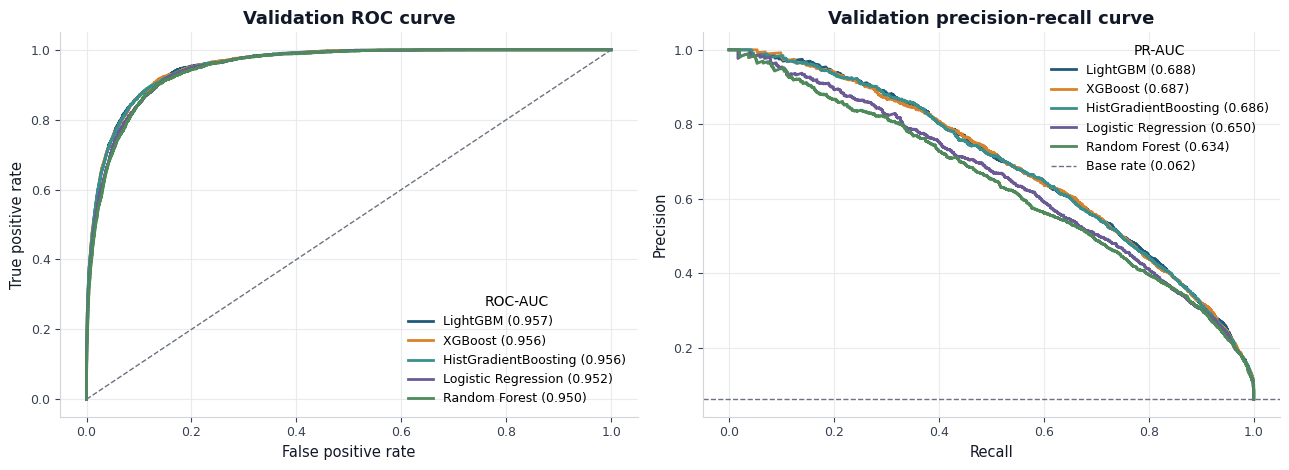

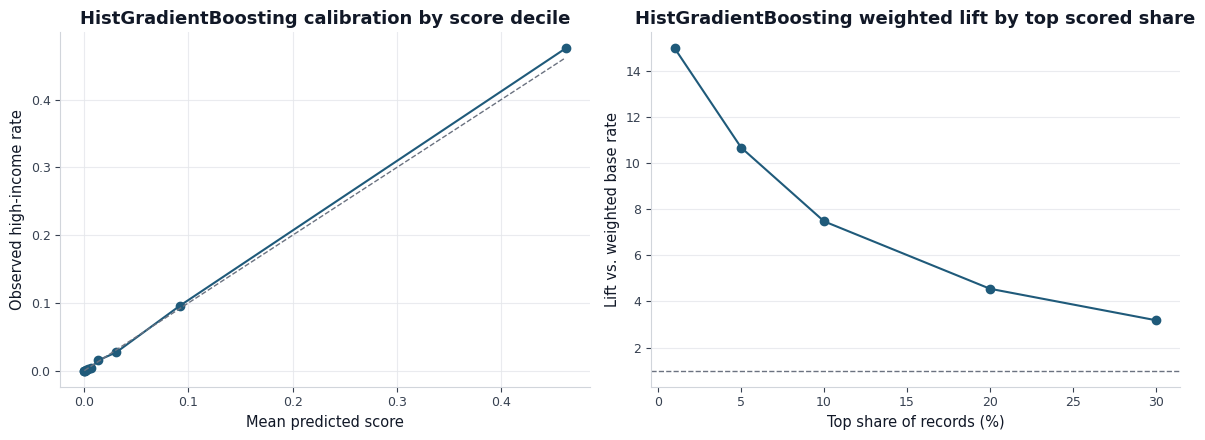

,mean_score,observed_rate,n
0,0.0001,0.0000,5048
1,0.0001,0.0000,3846
2,0.0002,0.0000,3078
3,0.0014,0.0008,3990
4,0.0031,0.0020,3991
5,0.0064,0.0043,3991
6,0.0133,0.0150,3989
7,0.0307,0.0271,3991
8,0.0917,0.0957,3990
9,0.4620,0.4758,3991


In [12]:
plot_results = sorted(candidate_results, key=lambda r: average_precision_score(y_val, r["val_scores"]), reverse=True)
plot_results = plot_results[: min(5, len(plot_results))]

# Report figure: traditional ROC and precision-recall curves for candidate model families.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for idx, result in enumerate(plot_results):
    color = REPORT_LINE_COLORS[idx % len(REPORT_LINE_COLORS)]
    fpr, tpr, _ = roc_curve(y_val, result["val_scores"])
    roc_auc = roc_auc_score(y_val, result["val_scores"])
    axes[0].plot(fpr, tpr, label=f'{result["model"]} ({roc_auc:.3f})', color=color, linewidth=2)
axes[0].plot([0, 1], [0, 1], linestyle="--", color=REPORT_PALETTE["gray"], linewidth=1)
axes[0].set_title("Validation ROC curve")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend(title="ROC-AUC", loc="lower right")
polish_axes(axes[0], grid_axis="both")

base_rate = y_val.mean()
for idx, result in enumerate(plot_results):
    color = REPORT_LINE_COLORS[idx % len(REPORT_LINE_COLORS)]
    precision, recall, _ = precision_recall_curve(y_val, result["val_scores"])
    pr_auc = average_precision_score(y_val, result["val_scores"])
    axes[1].plot(recall, precision, label=f'{result["model"]} ({pr_auc:.3f})', color=color, linewidth=2)
axes[1].axhline(base_rate, linestyle="--", color=REPORT_PALETTE["gray"], linewidth=1, label=f"Base rate ({base_rate:.3f})")
axes[1].set_title("Validation precision-recall curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(title="PR-AUC", loc="upper right")
polish_axes(axes[1], grid_axis="both")
fig.tight_layout()
save_report_figure(fig, "classification_roc_precision_recall_curves.png")
plt.show()

# Notebook diagnostics: calibration by score decile and selected-model lift.
calib = pd.DataFrame({"score": selected_val_scores, "y": y_val.to_numpy()})
# qcut keeps bins roughly equal-sized; duplicates='drop' handles tied scores gracefully.
calib["score_bin"] = pd.qcut(calib["score"], q=10, duplicates="drop")
calib_summary = calib.groupby("score_bin", observed=True).agg(
    mean_score=("score", "mean"),
    observed_rate=("y", "mean"),
    n=("y", "size"),
)
selected_lift_val = lift_table(y_val, selected_val_scores, sample_weight=w_val)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(calib_summary["mean_score"], calib_summary["observed_rate"], marker="o", color=REPORT_PALETTE["blue"])
max_score = calib_summary["mean_score"].max()
axes[0].plot([0, max_score], [0, max_score], linestyle="--", color=REPORT_PALETTE["gray"], linewidth=1)
axes[0].set_title(f"{selected_model_name} calibration by score decile")
axes[0].set_xlabel("Mean predicted score")
axes[0].set_ylabel("Observed high-income rate")
polish_axes(axes[0], grid_axis="both")

axes[1].plot(selected_lift_val["top_share_records_pct"], selected_lift_val["lift_vs_base"], marker="o", color=REPORT_PALETTE["blue"])
axes[1].axhline(1.0, linestyle="--", color=REPORT_PALETTE["gray"], linewidth=1)
axes[1].set_title(f"{selected_model_name} weighted lift by top scored share")
axes[1].set_xlabel("Top share of records (%)")
axes[1].set_ylabel("Lift vs. weighted base rate")
polish_axes(axes[1])
fig.tight_layout()
plt.show()

calib_summary.reset_index(drop=True).round(4)

### Observations

| # | Observation | Modeling implication |
|---|---|---|
| 1 | Validation comparison selects a single final model before test is touched. | Downstream thresholds, ablation, and bundle use one model family. |
| 2 | Brier and calibration are diagnostic only. | ROI is based on observed validation precision in ranked bands, not raw probability calibration. |

<a id="thresholds"></a>

## Threshold framework + capacity bands

- Addresses [Initial plan](#initial-plan) row 3 and row 10.
- Use validation behavior to show how business constraints map to thresholds or ranked contact bands.

In [13]:
def threshold_sweep(y_true, scores, sample_weight=None, thresholds=(0.05, 0.10, 0.20, 0.30, 0.50)):
    y_arr = np.asarray(y_true)
    score_arr = np.asarray(scores)
    weight_arr = np.ones_like(score_arr, dtype=float) if sample_weight is None else np.asarray(sample_weight, dtype=float)
    total_pos_weight = (weight_arr * y_arr).sum()
    rows = []
    # Fixed score cutoffs are useful diagnostics, but not necessarily the final campaign rule.
    for thr in thresholds:
        flagged = score_arr >= thr
        contacted_weight = weight_arr[flagged].sum()
        positive_weight = (weight_arr[flagged] * y_arr[flagged]).sum()
        precision = positive_weight / contacted_weight if contacted_weight > 0 else np.nan
        recall = positive_weight / total_pos_weight if total_pos_weight > 0 else np.nan
        rows.append({
            "threshold": thr,
            "contacted_records": int(flagged.sum()),
            "share_records_pct": flagged.mean() * 100,
            "contacted_weight": contacted_weight,
            "positive_weight": positive_weight,
            "precision": precision,
            "recall": recall,
        })
    return pd.DataFrame(rows)

threshold_table = threshold_sweep(y_val, selected_val_scores)
weighted_threshold_table = threshold_sweep(y_val, selected_val_scores, sample_weight=w_val)

print("Unweighted threshold sweep")
display(threshold_table.round(4))
print("Weighted threshold sweep")
display(weighted_threshold_table.round(4))

Unweighted threshold sweep


,threshold,contacted_records,share_records_pct,contacted_weight,positive_weight,precision,recall
0,0.05,7803,19.5539,7803.0,2273.0,0.2913,0.9176
1,0.10,5474,13.7176,5474.0,2107.0,0.3849,0.8506
2,0.20,3471,8.6982,3471.0,1806.0,0.5203,0.7291
3,0.30,2549,6.3877,2549.0,1563.0,0.6132,0.6310
4,0.50,1530,3.8341,1530.0,1139.0,0.7444,0.4598


Weighted threshold sweep


,threshold,contacted_records,share_records_pct,contacted_weight,positive_weight,precision,recall
0,0.05,7803,19.5539,13810968.21,4155793.29,0.3009,0.9229
1,0.10,5474,13.7176,9772982.96,3837821.92,0.3927,0.8523
2,0.20,3471,8.6982,6182072.93,3276360.32,0.5300,0.7276
3,0.30,2549,6.3877,4547806.46,2844389.17,0.6254,0.6317
4,0.50,1530,3.8341,2733487.57,2077055.10,0.7599,0.4613


In [14]:
def capacity_band_table(y_true, scores, sample_weight=None, bands=((0.00, 0.05), (0.05, 0.20), (0.20, 1.00))):
    y_arr = np.asarray(y_true)
    score_arr = np.asarray(scores)
    weight_arr = np.ones_like(score_arr, dtype=float) if sample_weight is None else np.asarray(sample_weight, dtype=float)
    # Bands are disjoint score-ranked slices, so top 5%-20% means the incremental audience after top 5%.
    order = np.argsort(-score_arr)
    y_sorted = y_arr[order]
    score_sorted = score_arr[order]
    w_sorted = weight_arr[order]
    base_rate = np.average(y_arr, weights=weight_arr)
    total_pos_weight = (weight_arr * y_arr).sum()
    n = len(y_sorted)
    rows = []
    for lo, hi in bands:
        start = int(np.floor(n * lo))
        end = int(np.floor(n * hi)) if hi < 1 else n
        y_band = y_sorted[start:end]
        s_band = score_sorted[start:end]
        w_band = w_sorted[start:end]
        contacted = w_band.sum()
        positives = (w_band * y_band).sum()
        precision = positives / contacted
        rows.append({
            "band": f"top {lo:.0%}-{hi:.0%}" if lo > 0 else f"top {hi:.0%}",
            "band_start_pct": lo * 100,
            "band_end_pct": hi * 100,
            "score_min": s_band.min(),
            "score_max": s_band.max(),
            "rows": len(y_band),
            "weighted_contacted_population": contacted,
            "weighted_precision": precision,
            "weighted_recall": positives / total_pos_weight,
            "lift_vs_base": precision / base_rate,
            "weighted_observed_positives": positives,
        })
    return pd.DataFrame(rows)

selected_val_bands = capacity_band_table(y_val, selected_val_scores, sample_weight=w_val)
selected_val_bands.round(4)

,band,band_start_pct,band_end_pct,score_min,score_max,rows,weighted_contacted_population,weighted_precision,weighted_recall,lift_vs_base,weighted_observed_positives
0,top 5%,0.0,5.0,0.3957,0.9901,1995,3576257.35,0.6925,0.5500,10.6777,2476685.45
1,top 5%-20%,5.0,20.0,0.0477,0.3950,5986,10549505.53,0.1604,0.3757,2.4727,1691892.76
2,top 20%-100%,20.0,100.0,0.0000,0.0477,31924,55302387.03,0.0060,0.0743,0.0932,334406.65


In [15]:
CONTACT_COST = 5
EXPECTED_VALUE_PER_TRUE_POSITIVE = 200
break_even_precision = CONTACT_COST / EXPECTED_VALUE_PER_TRUE_POSITIVE


def campaign_economics_from_bands(
    bands: pd.DataFrame,
    contact_cost: float = CONTACT_COST,
    expected_value_per_true_positive: float = EXPECTED_VALUE_PER_TRUE_POSITIVE,
) -> tuple[pd.DataFrame, dict]:
    break_even = contact_cost / expected_value_per_true_positive
    campaign = bands.copy()
    campaign["expected_revenue_per_contact"] = campaign["weighted_precision"] * expected_value_per_true_positive
    campaign["expected_profit_per_contact"] = campaign["expected_revenue_per_contact"] - contact_cost
    campaign["above_break_even"] = campaign["weighted_precision"] >= break_even

    # Recommend the largest profitable cumulative reach, not just the first profitable band.
    profitable = campaign.loc[campaign["above_break_even"]].copy()
    if len(profitable):
        max_profitable_row = profitable.iloc[-1]
        recommended_reach_pct = float(max_profitable_row["band_end_pct"])
        recommended_min_score = float(max_profitable_row["score_min"])
        recommended_band = f"top {recommended_reach_pct:.0f}%"
        profitable_bands = profitable["band"].tolist()
    else:
        recommended_reach_pct = 0.0
        recommended_min_score = np.nan
        recommended_band = None
        profitable_bands = []

    thresholds = {
        "illustrative_break_even_precision": break_even,
        "recommended_band": recommended_band,
        "recommended_reach_pct": recommended_reach_pct,
        "recommended_min_score": recommended_min_score,
        "profitable_bands": profitable_bands,
        "capacity_bands": {
            "top_5pct_min_score": float(campaign.loc[campaign["band_end_pct"] == 5, "score_min"].iloc[0]),
            "top_20pct_min_score": float(campaign.loc[campaign["band_end_pct"] == 20, "score_min"].iloc[0]),
        },
    }
    return campaign, thresholds


selected_campaign_table, candidate_recommended_thresholds = campaign_economics_from_bands(selected_val_bands)

print(f"Break-even precision: {break_even_precision:.2%}")
print("Selected-model recommended reach:", candidate_recommended_thresholds["recommended_band"])
selected_campaign_table[[
    "band",
    "weighted_precision",
    "lift_vs_base",
    "expected_revenue_per_contact",
    "expected_profit_per_contact",
    "above_break_even",
]].round(4)

Break-even precision: 2.50%
Selected-model recommended reach: top 20%


,band,weighted_precision,lift_vs_base,expected_revenue_per_contact,expected_profit_per_contact,above_break_even
0,top 5%,0.6925,10.6777,138.5071,133.5071,True
1,top 5%-20%,0.1604,2.4727,32.0753,27.0753,True
2,top 20%-100%,0.0060,0.0932,1.2094,-3.7906,False


### Observations

| # | Observation | Modeling implication |
|---|---|---|
| 1 | Fixed score cutoffs and ranked capacity bands answer different business questions. | The campaign recommendation should use ranked bands, not a default 0.5 cutoff. |
| 2 | The ROI example uses observed validation precision by band. | This avoids over-interpreting uncalibrated model scores as literal probabilities. |
| 3 | Recommendation chooses the largest profitable cumulative reach. | If top 5% and top 5%-20% both clear break-even, recommend top 20%. |

<a id="ablation"></a>

## Feature importance + drop-candidate ablation

- Addresses [Initial plan](#initial-plan) rows 9, 12, and 13.
- Use validation PR-AUC to test EDA drop-candidate hypotheses without exhaustive tuning.

In [16]:
def fit_selected_family(feature_cols: list[str], verbose: bool = False):
    cat_cols = [c for c in categorical_model_features if c in feature_cols]
    numeric_cols = [c for c in numeric_model_features if c in feature_cols]
    Xtr = X_train_full[feature_cols]
    Xva = X_val_full[feature_cols]

    if selected_model_name == "Logistic Regression":
        # Reuse the selected education representation; logreg ablation is mainly for completeness.
        education_mode = selected_education_mode or "raw"
        Xtr_lr = add_logreg_features(Xtr, education_mode=education_mode)
        Xva_lr = add_logreg_features(Xva, education_mode=education_mode)
        cat_lr, num_lr = logreg_columns(education_mode)
        cat_lr = [c for c in cat_lr if c in Xtr_lr.columns]
        num_lr = [c for c in num_lr if c in Xtr_lr.columns]
        model = Pipeline(steps=[
            ("preprocess", ColumnTransformer([
                ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat_lr),
                ("num", StandardScaler(), num_lr),
            ], remainder="drop")),
            ("model", LogisticRegression(max_iter=2000, class_weight=None, random_state=RANDOM_STATE)),
        ])
        model.fit(Xtr_lr, y_train)
        return model, model.predict_proba(Xva_lr)[:, 1]

    if selected_model_name == "Random Forest":
        model = make_onehot_pipeline(RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=20,
            class_weight=None,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ))
        model.fit(Xtr, y_train)
        return model, model.predict_proba(Xva)[:, 1]

    if selected_model_name == "HistGradientBoosting":
        Xtr_ord = to_ordinal_features(Xtr, cat_cols)
        Xva_ord = to_ordinal_features(Xva, cat_cols)
        cat_mask = [c in cat_cols for c in feature_cols]
        model = HistGradientBoostingClassifier(
            max_iter=300,
            learning_rate=0.05,
            l2_regularization=0.0,
            categorical_features=cat_mask,
            early_stopping=True,
            random_state=RANDOM_STATE,
        )
        model.fit(Xtr_ord, y_train)
        return model, model.predict_proba(Xva_ord)[:, 1]

    if selected_model_name == "XGBoost":
        if selected_representation == "native":
            model = XGBClassifier(
                n_estimators=400,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="aucpr",
                tree_method="hist",
                enable_categorical=True,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
            model.fit(Xtr, y_train, eval_set=[(Xva, y_val)], verbose=False)
            return model, model.predict_proba(Xva)[:, 1]
        Xtr_ord = to_ordinal_features(Xtr, cat_cols)
        Xva_ord = to_ordinal_features(Xva, cat_cols)
        model = XGBClassifier(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="aucpr",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        model.fit(Xtr_ord, y_train, eval_set=[(Xva_ord, y_val)], verbose=False)
        return model, model.predict_proba(Xva_ord)[:, 1]

    if selected_model_name == "LightGBM":
        model = LGBMClassifier(
            objective="binary",
            n_estimators=2000,
            learning_rate=0.05,
            num_leaves=63,
            min_child_samples=50,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1,
        )
        model.fit(
            Xtr,
            y_train,
            eval_set=[(Xva, y_val)],
            eval_metric="auc",
            categorical_feature=cat_cols,
            callbacks=[early_stopping(stopping_rounds=50, verbose=verbose), log_evaluation(period=0)],
        )
        return model, model.predict_proba(Xva)[:, 1]

    raise ValueError(f"Unsupported selected model: {selected_model_name}")


def selected_model_feature_importance(model, feature_cols: list[str]) -> pd.DataFrame:
    if selected_model_name == "LightGBM":
        return (
            pd.DataFrame({
                "feature": model.booster_.feature_name(),
                "gain": model.booster_.feature_importance(importance_type="gain"),
                "split": model.booster_.feature_importance(importance_type="split"),
            })
            .sort_values("gain", ascending=False)
            .reset_index(drop=True)
        )
    if selected_model_name == "XGBoost":
        booster = model.get_booster()
        gain = booster.get_score(importance_type="gain")
        weight = booster.get_score(importance_type="weight")
        rows = []
        for f in feature_cols:
            rows.append({"feature": f, "gain": gain.get(f, 0.0), "split": weight.get(f, 0.0)})
        return pd.DataFrame(rows).sort_values("gain", ascending=False).reset_index(drop=True)
    if selected_model_name == "Random Forest":
        names = model.named_steps["preprocess"].get_feature_names_out()
        return (
            pd.DataFrame({"feature": names, "importance": model.named_steps["model"].feature_importances_})
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )
    if selected_model_name == "Logistic Regression":
        names = model.named_steps["preprocess"].get_feature_names_out()
        coef = model.named_steps["model"].coef_[0]
        return (
            pd.DataFrame({"feature": names, "coefficient": coef, "abs_coefficient": np.abs(coef)})
            .sort_values("abs_coefficient", ascending=False)
            .reset_index(drop=True)
        )
    return pd.DataFrame({"note": ["Feature importance skipped for selected model family."]})

importance = selected_model_feature_importance(selected_model, feature_cols_full)
importance.head(20).round(4)

,note
0,Feature importance skipped for selected model family.


In [17]:
baseline_selected_pr = average_precision_score(y_val, selected_val_scores)
SAFE_DROP_TOLERANCE = 0.005

ablation_groups = {
    "drop detailed industry/occupation": ["detailed industry recode", "detailed occupation recode"],
    "drop detailed household status": ["detailed household and family stat"],
    "drop previous residence": ["state of previous residence", "region of previous residence"],
    "drop country of birth family": [
        "country of birth father",
        "country of birth mother",
        "country of birth self",
    ],
    "drop year": ["year"],
}

ablation_rows = []
for group_name, drop_cols in ablation_groups.items():
    drop_cols = [c for c in drop_cols if c in feature_cols_full]
    candidate_features = [c for c in feature_cols_full if c not in drop_cols]
    candidate_model, candidate_scores = fit_selected_family(candidate_features)
    pr_auc = average_precision_score(y_val, candidate_scores)
    delta = pr_auc - baseline_selected_pr
    safe_drop = delta >= -SAFE_DROP_TOLERANCE
    ablation_rows.append({
        "group": group_name,
        "dropped_features": ", ".join(drop_cols),
        "n_features": len(candidate_features),
        "val_pr_auc": pr_auc,
        "delta_vs_selected_full": delta,
        "safe_drop_individual": safe_drop,
    })

ablation_results = pd.DataFrame(ablation_rows).sort_values("delta_vs_selected_full", ascending=False)
ablation_results.round(5)

,group,dropped_features,n_features,val_pr_auc,delta_vs_selected_full,safe_drop_individual
3,drop country of birth family,"country of birth father, country of birth mother, country of birth self",34,0.68803,0.00195,True
2,drop previous residence,"state of previous residence, region of previous residence",35,0.68715,0.00107,True
4,drop year,year,36,0.68608,0.00000,True
1,drop detailed household status,detailed household and family stat,36,0.68455,-0.00153,True
0,drop detailed industry/occupation,"detailed industry recode, detailed occupation recode",35,0.67303,-0.01305,False


In [18]:
safe_groups = ablation_results.loc[ablation_results["safe_drop_individual"], "group"].tolist()
proposed_drop_cols = sorted({col for group in safe_groups for col in ablation_groups[group] if col in feature_cols_full})
proposed_feature_cols = [c for c in feature_cols_full if c not in proposed_drop_cols]

if proposed_drop_cols:
    proposed_model, proposed_val_scores = fit_selected_family(proposed_feature_cols)
    proposed_pr = average_precision_score(y_val, proposed_val_scores)
    proposed_delta = proposed_pr - baseline_selected_pr
else:
    proposed_model, proposed_val_scores = selected_model, selected_val_scores
    proposed_pr = baseline_selected_pr
    proposed_delta = 0.0

if proposed_delta >= -SAFE_DROP_TOLERANCE:
    final_feature_cols = proposed_feature_cols
    final_drop_cols = proposed_drop_cols
    final_feature_choice = "drop safe groups"
else:
    final_feature_cols = feature_cols_full
    final_drop_cols = []
    final_feature_choice = "keep full modeling feature set"

sensitive_drop_cols = [c for c in sensitive_attribute_cols if c in final_feature_cols]
sensitive_feature_cols = [c for c in final_feature_cols if c not in sensitive_drop_cols]
sensitive_model, sensitive_val_scores = fit_selected_family(sensitive_feature_cols)
sensitive_pr = average_precision_score(y_val, sensitive_val_scores)
sensitive_delta = sensitive_pr - average_precision_score(y_val, proposed_val_scores if final_feature_choice == "drop safe groups" else selected_val_scores)

feature_selection_summary = pd.DataFrame([
    {
        "candidate": "selected full modeling feature set",
        "n_features": len(feature_cols_full),
        "val_pr_auc": baseline_selected_pr,
        "delta_vs_selected_full": 0.0,
    },
    {
        "candidate": "combined safe-drop proposal",
        "n_features": len(proposed_feature_cols),
        "val_pr_auc": proposed_pr,
        "delta_vs_selected_full": proposed_delta,
    },
    {
        "candidate": "report-only exclude sensitive attributes",
        "n_features": len(sensitive_feature_cols),
        "val_pr_auc": sensitive_pr,
        "delta_vs_final_candidate": sensitive_delta,
    },
])

print("Final feature choice:", final_feature_choice)
print("Dropped columns:", final_drop_cols)
print("Sensitive columns checked:", sensitive_drop_cols)
feature_selection_summary.round(5)

Final feature choice: drop safe groups
Dropped columns: ['country of birth father', 'country of birth mother', 'country of birth self', 'detailed household and family stat', 'region of previous residence', 'state of previous residence', 'year']
Sensitive columns checked: ['sex', 'race', 'hispanic origin', 'citizenship']


,candidate,n_features,val_pr_auc,delta_vs_selected_full,delta_vs_final_candidate
0,selected full modeling feature set,37,0.68608,0.0000,NaN
1,combined safe-drop proposal,30,0.68978,0.0037,NaN
2,report-only exclude sensitive attributes,26,0.67301,NaN,-0.01677


### Observations

| # | Observation | Modeling implication |
|---|---|---|
| 1 | Ablation uses the selected model family rather than rerunning all benchmark families. | Feature-selection evidence stays aligned with the final candidate. |
| 2 | Sensitive-attribute exclusion is report-only evidence. | It quantifies trade-off without changing the technical selected model. |

### Cross-validation stability check

Before the final test-set evaluation, run a 5-fold stratified cross-validation check on the training split only. This is not hyperparameter tuning; it tests whether the selected model family and final feature set are stable across different training folds while keeping validation and test available for threshold selection and final reporting.

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def fit_selected_family_cv_fold(fold_train: pd.DataFrame, fold_holdout: pd.DataFrame, feature_cols: list[str]):
    fold_dtype_map = fit_categorical_dtype_map(fold_train, categorical_model_features)
    Xtr = apply_categorical_dtype_map(fold_train, fold_dtype_map)[feature_cols]
    Xho = apply_categorical_dtype_map(fold_holdout, fold_dtype_map)[feature_cols]
    ytr = fold_train[target_col]
    yho = fold_holdout[target_col]

    cat_cols = [c for c in categorical_model_features if c in feature_cols]

    if selected_model_name == "HistGradientBoosting":
        Xtr_model = to_ordinal_features(Xtr, cat_cols)
        Xho_model = to_ordinal_features(Xho, cat_cols)
        cat_mask = [c in cat_cols for c in feature_cols]
        model = HistGradientBoostingClassifier(
            max_iter=300,
            learning_rate=0.05,
            l2_regularization=0.0,
            categorical_features=cat_mask,
            early_stopping=True,
            random_state=RANDOM_STATE,
        )
        model.fit(Xtr_model, ytr)
        return model.predict_proba(Xho_model)[:, 1]

    if selected_model_name == "LightGBM":
        model = LGBMClassifier(
            objective="binary",
            n_estimators=2000,
            learning_rate=0.05,
            num_leaves=63,
            min_child_samples=50,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1,
        )
        model.fit(
            Xtr,
            ytr,
            eval_set=[(Xho, yho)],
            eval_metric="auc",
            categorical_feature=cat_cols,
            callbacks=[early_stopping(stopping_rounds=50, verbose=False), log_evaluation(period=0)],
        )
        return model.predict_proba(Xho)[:, 1]

    if selected_model_name == "XGBoost":
        if selected_representation == "native":
            model = XGBClassifier(
                n_estimators=400,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="aucpr",
                tree_method="hist",
                enable_categorical=True,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
            model.fit(Xtr, ytr, eval_set=[(Xho, yho)], verbose=False)
            return model.predict_proba(Xho)[:, 1]
        Xtr_model = to_ordinal_features(Xtr, cat_cols)
        Xho_model = to_ordinal_features(Xho, cat_cols)
        model = XGBClassifier(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="aucpr",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        model.fit(Xtr_model, ytr, eval_set=[(Xho_model, yho)], verbose=False)
        return model.predict_proba(Xho_model)[:, 1]

    if selected_model_name == "Random Forest":
        model = make_onehot_pipeline(RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=20,
            class_weight=None,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ))
        model.fit(Xtr, ytr)
        return model.predict_proba(Xho)[:, 1]

    if selected_model_name == "Logistic Regression":
        education_mode = selected_education_mode or "raw"
        Xtr_lr = add_logreg_features(Xtr, education_mode=education_mode)
        Xho_lr = add_logreg_features(Xho, education_mode=education_mode)
        cat_lr, num_lr = logreg_columns(education_mode)
        cat_lr = [c for c in cat_lr if c in Xtr_lr.columns]
        num_lr = [c for c in num_lr if c in Xtr_lr.columns]
        model = Pipeline(steps=[
            ("preprocess", ColumnTransformer([
                ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat_lr),
                ("num", StandardScaler(), num_lr),
            ], remainder="drop")),
            ("model", LogisticRegression(max_iter=2000, class_weight=None, random_state=RANDOM_STATE)),
        ])
        model.fit(Xtr_lr, ytr)
        return model.predict_proba(Xho_lr)[:, 1]

    raise ValueError(f"Unsupported selected model: {selected_model_name}")


cv_rows = []
for fold, (fit_idx, holdout_idx) in enumerate(cv.split(df_train, y_train), start=1):
    fold_train = df_train.iloc[fit_idx].copy()
    fold_holdout = df_train.iloc[holdout_idx].copy()
    fold_scores = fit_selected_family_cv_fold(fold_train, fold_holdout, final_feature_cols)
    fold_y = fold_holdout[target_col]
    fold_w = fold_holdout[weight_col]
    top10 = lift_table(fold_y, fold_scores, sample_weight=fold_w, cutoffs=(0.10,)).iloc[0]
    cv_rows.append({
        "fold": fold,
        "rows": len(fold_holdout),
        "positive_rate_pct": fold_y.mean() * 100,
        "weighted_positive_rate_pct": np.average(fold_y, weights=fold_w) * 100,
        "pr_auc": average_precision_score(fold_y, fold_scores),
        "weighted_pr_auc": average_precision_score(fold_y, fold_scores, sample_weight=fold_w),
        "roc_auc": roc_auc_score(fold_y, fold_scores),
        "weighted_roc_auc": roc_auc_score(fold_y, fold_scores, sample_weight=fold_w),
        "brier": brier_score_loss(fold_y, fold_scores),
        "top_10pct_weighted_precision": top10["weighted_precision"],
        "top_10pct_lift": top10["lift_vs_base"],
    })

cv_results = pd.DataFrame(cv_rows)
cv_summary = (
    cv_results[[
        "pr_auc",
        "weighted_pr_auc",
        "roc_auc",
        "weighted_roc_auc",
        "brier",
        "top_10pct_weighted_precision",
        "top_10pct_lift",
    ]]
    .agg(["mean", "std"])
    .T
    .reset_index()
    .rename(columns={"index": "metric"})
)

print(f"5-fold CV stability check for final {selected_model_name} feature set")
display(cv_results.round(4))
display(cv_summary.round(4))

5-fold CV stability check for final HistGradientBoosting feature set


,fold,rows,positive_rate_pct,weighted_positive_rate_pct,pr_auc,weighted_pr_auc,roc_auc,weighted_roc_auc,brier,top_10pct_weighted_precision,top_10pct_lift
0,1,23943,6.2064,6.4646,0.6625,0.6541,0.9498,0.9484,0.0332,0.4754,7.3536
1,2,23943,6.2064,6.1958,0.6550,0.6624,0.9485,0.9496,0.0337,0.4570,7.3752
2,3,23943,6.2064,6.3565,0.6542,0.6739,0.9515,0.9535,0.0333,0.4809,7.5657
3,4,23942,6.2025,6.3592,0.6841,0.6850,0.9543,0.9535,0.0319,0.4767,7.4956
4,5,23942,6.2067,6.5479,0.6768,0.6809,0.9532,0.9511,0.0326,0.4764,7.2755


,metric,mean,std
0,pr_auc,0.6665,0.0134
1,weighted_pr_auc,0.6713,0.0129
2,roc_auc,0.9515,0.0024
3,weighted_roc_auc,0.9512,0.0023
4,brier,0.0329,0.0007
5,top_10pct_weighted_precision,0.4733,0.0094
6,top_10pct_lift,7.4131,0.1162


<a id="final-test"></a>

## Final test evaluation + saved artifact

- Addresses all classification deliverables.
- Refit the selected model family on train only with the selected feature set, use validation for early stopping when supported, then evaluate test once.

In [20]:
# Reuse already-trained models when the selected feature set matches a prior fit.
if final_feature_cols == proposed_feature_cols and proposed_drop_cols:
    final_model = proposed_model
    final_val_scores = proposed_val_scores
elif final_feature_cols == feature_cols_full:
    final_model = selected_model
    final_val_scores = selected_val_scores
else:
    final_model, final_val_scores = fit_selected_family(final_feature_cols)

X_test_final_base = X_test_full[final_feature_cols]
final_test_scores = predict_model_scores(
    final_model,
    selected_representation if selected_model_name != "Logistic Regression" else "logreg",
    X_test_final_base,
    education_mode=selected_education_mode,
)

final_metrics = pd.DataFrame([
    metric_row(f"Final {selected_model_name}", "val", y_val, final_val_scores),
    metric_row(f"Final {selected_model_name}", "val", y_val, final_val_scores, sample_weight=w_val),
    metric_row(f"Final {selected_model_name}", "test", y_test, final_test_scores),
    metric_row(f"Final {selected_model_name}", "test", y_test, final_test_scores, sample_weight=w_test),
])
final_metrics.round(4)

,model,split,weighting,pr_auc,roc_auc,brier,best_f1_threshold_diagnostic,best_f1_diagnostic
0,Final HistGradientBoosting,val,unweighted,0.6898,0.9563,0.0317,0.3022,0.6249
1,Final HistGradientBoosting,val,weighted,0.7016,0.9576,0.0325,0.3412,0.6314
2,Final HistGradientBoosting,test,unweighted,0.6738,0.9516,0.0325,0.3175,0.6191
3,Final HistGradientBoosting,test,weighted,0.6791,0.9510,0.0332,0.3151,0.6236


Final-model validation capacity bands + economics


,band,score_min,weighted_precision,lift_vs_base,expected_profit_per_contact,above_break_even
0,top 5%,0.3998,0.7041,10.8562,135.8229,True
1,top 5%-20%,0.0461,0.1575,2.4279,26.4933,True
2,top 20%-100%,0.0000,0.0060,0.0919,-3.8078,False


Final-model recommended reach: top 20%

Weighted test lift


,top_share_records_pct,rows_contacted,weighted_contacted_population,weighted_positives_captured,weighted_precision,lift_vs_base,weighted_recall
0,1.0,400,711401.49,685807.68,0.9640,15.0980,0.1551
1,5.0,1996,3468699.79,2424364.26,0.6989,10.9462,0.5483
2,10.0,3991,6977053.42,3312424.13,0.4748,7.4354,0.7491
3,20.0,7981,13970242.64,4006556.34,0.2868,4.4916,0.9061
4,30.0,11972,20952603.92,4237941.49,0.2023,3.1677,0.9584


Weighted test capacity bands


,band,band_start_pct,band_end_pct,score_min,score_max,rows,weighted_contacted_population,weighted_precision,weighted_recall,lift_vs_base,weighted_observed_positives
0,top 5%,0.0,5.0,0.4050,0.9955,1995,3466466.29,0.6994,0.5483,10.9532,2424364.26
1,top 5%-20%,5.0,20.0,0.0472,0.4049,5986,10503776.35,0.1506,0.3578,2.3591,1582192.08
2,top 20%-100%,20.0,100.0,0.0000,0.0471,31924,55282853.31,0.0075,0.0939,0.1177,415325.69


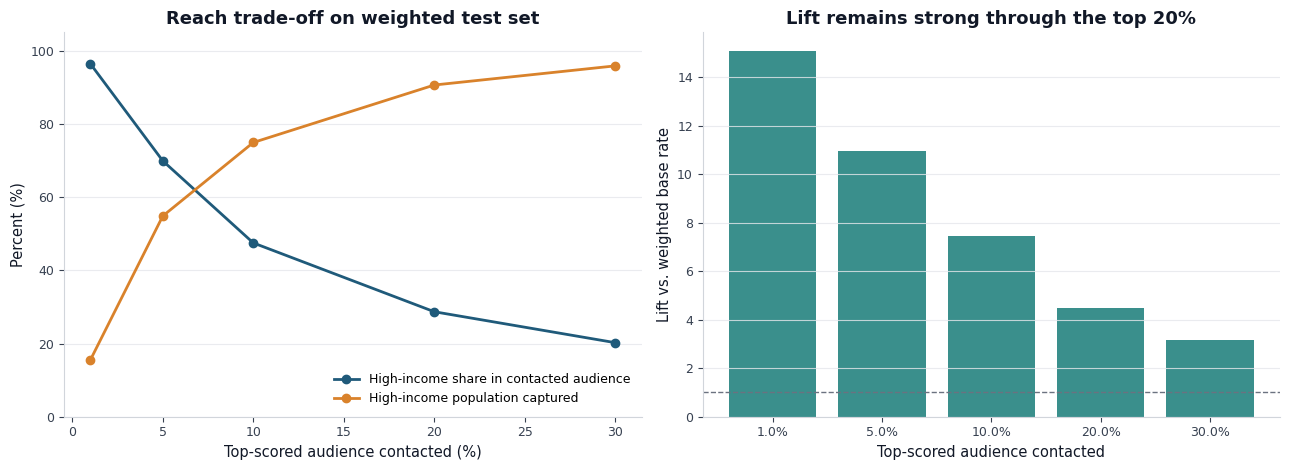

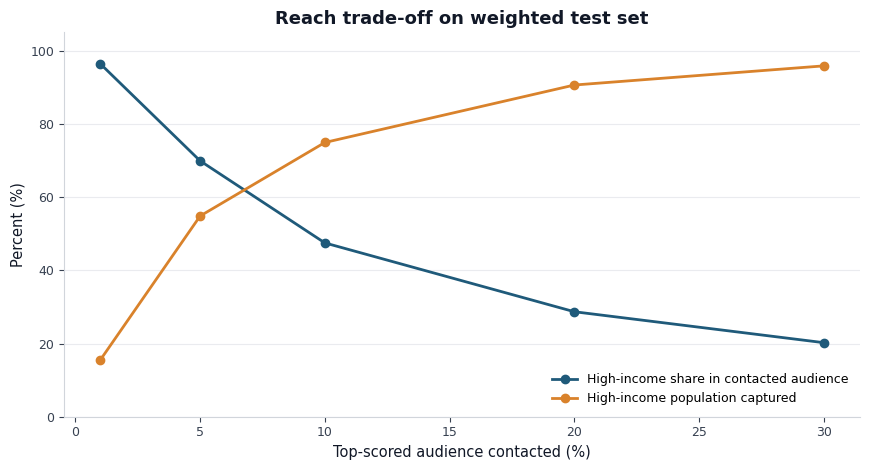

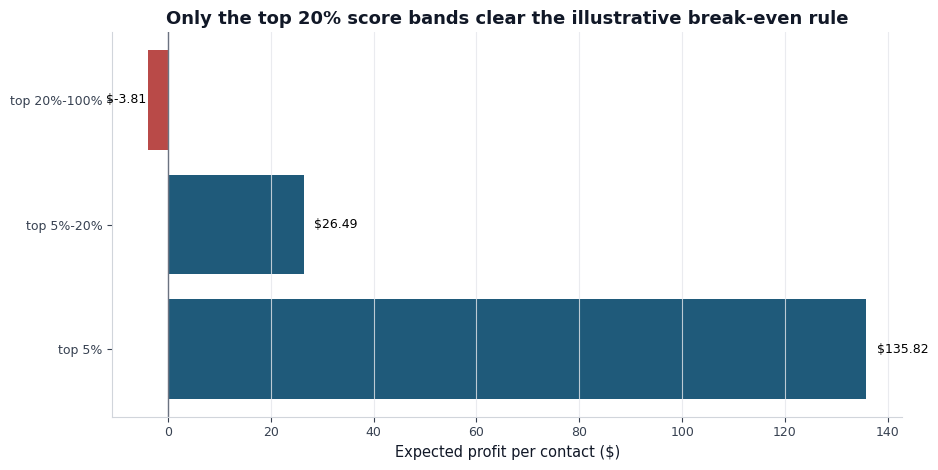

In [21]:
# Recompute thresholds from the final model's validation scores before saving the bundle.
final_val_bands = capacity_band_table(y_val, final_val_scores, sample_weight=w_val)
final_campaign_table, recommended_thresholds = campaign_economics_from_bands(final_val_bands)

final_test_lift = lift_table(y_test, final_test_scores, sample_weight=w_test)
final_test_bands = capacity_band_table(y_test, final_test_scores, sample_weight=w_test)

print("Final-model validation capacity bands + economics")
display(final_campaign_table[[
    "band",
    "score_min",
    "weighted_precision",
    "lift_vs_base",
    "expected_profit_per_contact",
    "above_break_even",
]].round(4))
print("Final-model recommended reach:", recommended_thresholds["recommended_band"])
print()
print("Weighted test lift")
display(final_test_lift.round(4))
print("Weighted test capacity bands")
display(final_test_bands.round(4))

# Report figure: how concentration and capture change as marketing expands reach.
lift_plot = final_test_lift.copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(lift_plot["top_share_records_pct"], lift_plot["weighted_precision"] * 100,
             marker="o", color=REPORT_PALETTE["blue"], linewidth=2, label="High-income share in contacted audience")
axes[0].plot(lift_plot["top_share_records_pct"], lift_plot["weighted_recall"] * 100,
             marker="o", color=REPORT_PALETTE["orange"], linewidth=2, label="High-income population captured")
axes[0].set_title("Reach trade-off on weighted test set")
axes[0].set_xlabel("Top-scored audience contacted (%)")
axes[0].set_ylabel("Percent (%)")
axes[0].set_ylim(0, 105)
axes[0].legend(loc="lower right")
polish_axes(axes[0])

axes[1].bar(lift_plot["top_share_records_pct"].astype(str) + "%", lift_plot["lift_vs_base"], color=REPORT_PALETTE["teal"])
axes[1].axhline(1.0, color=REPORT_PALETTE["gray"], linestyle="--", linewidth=1)
axes[1].set_title("Lift remains strong through the top 20%")
axes[1].set_xlabel("Top-scored audience contacted")
axes[1].set_ylabel("Lift vs. weighted base rate")
polish_axes(axes[1])
fig.tight_layout()
save_report_figure(fig, "classification_test_lift.png")
plt.show()

# Report figure: standalone reach trade-off curve for the Executive Summary.
fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.plot(lift_plot["top_share_records_pct"], lift_plot["weighted_precision"] * 100,
        marker="o", color=REPORT_PALETTE["blue"], linewidth=2, label="High-income share in contacted audience")
ax.plot(lift_plot["top_share_records_pct"], lift_plot["weighted_recall"] * 100,
        marker="o", color=REPORT_PALETTE["orange"], linewidth=2, label="High-income population captured")
ax.set_title("Reach trade-off on weighted test set")
ax.set_xlabel("Top-scored audience contacted (%)")
ax.set_ylabel("Percent (%)")
ax.set_ylim(0, 105)
ax.legend(loc="lower right")
polish_axes(ax)
fig.tight_layout()
save_report_figure(fig, "classification_reach_tradeoff.png")
plt.show()

# Report figure: validation economics for the recommended capacity bands.
econ_plot = final_campaign_table.copy()
econ_plot["profit_label"] = econ_plot["expected_profit_per_contact"].map(lambda x: f"${x:,.2f}")
colors = np.where(econ_plot["above_break_even"], REPORT_PALETTE["blue"], REPORT_PALETTE["red"])
fig, ax = plt.subplots(figsize=(9.5, 4.8))
y = np.arange(len(econ_plot))
ax.barh(y, econ_plot["expected_profit_per_contact"], color=colors)
ax.axvline(0, color=REPORT_PALETTE["gray"], linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(econ_plot["band"])
ax.set_xlabel("Expected profit per contact ($)")
ax.set_title("Only the top 20% score bands clear the illustrative break-even rule")
for yi, value, label in zip(y, econ_plot["expected_profit_per_contact"], econ_plot["profit_label"]):
    ha = "left" if value >= 0 else "right"
    offset = 2.0 if value >= 0 else -0.35
    ax.text(value + offset, yi, label, va="center", ha=ha, fontsize=9)
polish_axes(ax, grid_axis="x")
fig.tight_layout()
save_report_figure(fig, "classification_campaign_economics.png")
plt.show()

In [22]:
def predict_from_raw(raw_df: pd.DataFrame, bundle: dict) -> np.ndarray:
    X_base = prepare_raw_for_model(
        raw_df,
        bundle["categorical_dtype_map"],
        bundle["feature_cols"],
    )
    representation = bundle["feature_representation"]
    if representation == "logreg":
        X_model = add_logreg_features(X_base, education_mode=bundle["preprocessing_config"].get("logreg_education_mode", "raw"))
        return bundle["model"].predict_proba(X_model)[:, 1]
    if representation == "ordinal":
        X_model = to_ordinal_features(X_base, [c for c in bundle["categorical_cols"] if c in X_base.columns])
        return bundle["model"].predict_proba(X_model)[:, 1]
    return bundle["model"].predict_proba(X_base)[:, 1]


MODEL_DIR.mkdir(parents=True, exist_ok=True)

final_categorical_cols = [c for c in categorical_model_features if c in final_feature_cols]
final_numeric_cols = [c for c in numeric_model_features if c in final_feature_cols]
final_representation = selected_representation if selected_model_name != "Logistic Regression" else "logreg"

preprocessing_config = {
    "unknown_value": UNKNOWN_VALUE,
    "sentinel_to_unknown": {
        "all_categorical_columns": ["?"],
        "hispanic origin": ["NaN", "Do not know"],
    },
    "topcode_thresholds": TOPCODE_THRESHOLDS,
    "heavy_tailed_numeric": HEAVY_TAILED_NUMERIC,
    "artifact_drop_features": artifact_drop_features,
    "sensitive_attribute_cols": sensitive_attribute_cols,
    "unseen_category_policy": "map to Unknown before category casting",
    "logreg_education_mode": selected_education_mode,
}

bundle = {
    "model": final_model,
    "model_name": selected_model_name,
    "feature_representation": final_representation,
    "feature_cols": final_feature_cols,
    "categorical_cols": final_categorical_cols,
    "numeric_cols": final_numeric_cols,
    "categorical_dtype_map": categorical_dtype_map,
    "preprocessing_config": preprocessing_config,
    "thresholds": recommended_thresholds,
    "feature_selection": {
        "choice": final_feature_choice,
        "dropped_columns": final_drop_cols,
        "safe_drop_tolerance_pr_auc": SAFE_DROP_TOLERANCE,
        "sensitive_attribute_sensitivity": {
            "dropped_columns": sensitive_drop_cols,
            "val_pr_auc": float(sensitive_pr),
            "delta_vs_final_candidate": float(sensitive_delta),
            "report_only": True,
        },
    },
    "benchmark": {
        "candidate_validation_metrics": validation_comparison.to_dict(orient="records"),
        "selected_model": selected_model_name,
        "selected_representation": final_representation,
        "selection_reason": selection_reason,
        "cv_stability": {
            "fold_metrics": cv_results.to_dict(orient="records"),
            "summary": cv_summary.to_dict(orient="records"),
        },
    },
    "metadata": {
        "trained_at": datetime.now(timezone.utc).isoformat(),
        "random_state": RANDOM_STATE,
        "val_pr_auc": float(average_precision_score(y_val, final_val_scores)),
        "test_pr_auc": float(average_precision_score(y_test, final_test_scores)),
        "weighted_val_pr_auc": float(average_precision_score(y_val, final_val_scores, sample_weight=w_val)),
        "weighted_test_pr_auc": float(average_precision_score(y_test, final_test_scores, sample_weight=w_test)),
        "xgboost_version": xgb.__version__ if selected_model_name == "XGBoost" else None,
        "lightgbm_version": lgb.__version__ if selected_model_name == "LightGBM" else None,
        "sklearn_version": sklearn.__version__,
        "pandas_version": pd.__version__,
        "python_version": sys.version,
    },
}

joblib.dump(bundle, MODEL_PATH)
# Keep the previous filename updated as a compatibility alias for downstream notebooks that may expect it.
joblib.dump(bundle, LEGACY_MODEL_PATH)
loaded_bundle = joblib.load(MODEL_PATH)

raw_sample = raw_test.head(5)
roundtrip_scores = predict_from_raw(raw_sample, loaded_bundle)
notebook_scores = final_test_scores[:5]

assert np.allclose(roundtrip_scores, notebook_scores, atol=1e-9)

print("Saved bundle:", MODEL_PATH)
print("Saved compatibility alias:", LEGACY_MODEL_PATH)
print("Round-trip probabilities:", np.round(roundtrip_scores, 6).tolist())
print("Bundle keys:", sorted(loaded_bundle.keys()))

Saved bundle: ../outputs/models/income_classifier_bundle.joblib
Saved compatibility alias: ../outputs/models/lgbm_classifier.joblib
Round-trip probabilities: [2.7e-05, 0.054584, 3.3e-05, 2.6e-05, 0.436461]
Bundle keys: ['benchmark', 'categorical_cols', 'categorical_dtype_map', 'feature_cols', 'feature_representation', 'feature_selection', 'metadata', 'model', 'model_name', 'numeric_cols', 'preprocessing_config', 'thresholds']


### Closing observations

| # | Observation | Report-ready implication |
|---|---|---|
| 1 | The final model is selected on validation from common classifier families, then evaluated on test once. | The reported test metrics are not used for model selection. |
| 2 | Saved thresholds are recomputed from the final model's validation scores. | The artifact's campaign thresholds match the serialized model. |
| 3 | The saved artifact is a full bundle with preprocessing metadata. | Future scoring and segmentation can call `predict_from_raw()` on raw Census-format rows. |